In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
import sys
import os

os.chdir(r"c:\Projects\signia-fsl-recognition")
sys.path.insert(0, r"c:\Projects\signia-fsl-recognition")

from src.landmarks.dynamic_extractor import DynamicLandmarkExtractor

In [2]:
ROOT = Path(r"C:\Projects\signia-fsl-recognition")

MANIFEST = ROOT / "data" / "video_manifest.csv"

OUTPUT = (
    ROOT
    / "data"
    / "processed"
    / "GREETING"
)

SEQUENCE_DIR = OUTPUT / "raw_sequences"

SEQUENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
manifest = pd.read_csv(MANIFEST)

GREETING_5 = [
    "GOOD MORNING",
    "GOOD AFTERNOON",
    "GOOD EVENING",
    "HELLO",
    "THANK YOU"
]

manifest = manifest[
    manifest["label"].isin(
        GREETING_5
    )
]

manifest.shape

(103, 13)

Initialize extractor & sample

In [4]:
from src.landmarks.dynamic_extractor import DynamicLandmarkExtractor

extractor = DynamicLandmarkExtractor()

sequence, meta = extractor.extract_video(
    r"C:\Projects\signia-fsl-recognition\dynamic_raw\0\19.MOV"
)

print(sequence.shape)
print(meta)

c:\Projects\signia-fsl-recognition\fsl39\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(244, 126)
{'total_frames': 244, 'detected_frames': 107, 'detection_rate': 0.4385245901639344}


In [7]:
samples = [
    r"C:\Projects\signia-fsl-recognition\dynamic_raw\0\19.MOV",
    r"C:\Projects\signia-fsl-recognition\dynamic_raw\0\18.MOV",
    r"C:\Projects\signia-fsl-recognition\dynamic_raw\3\18.MOV",
    r"C:\Projects\signia-fsl-recognition\dynamic_raw\7\17.MOV",
]

for path in samples:
    seq, meta = extractor.extract_video(path)

    print(Path(path).name)
    print(seq.shape)
    print(meta)
    print()

19.MOV
(244, 126)
{'total_frames': 244, 'detected_frames': 107, 'detection_rate': 0.4385245901639344}

18.MOV
(244, 126)
{'total_frames': 244, 'detected_frames': 125, 'detection_rate': 0.5122950819672131}

18.MOV
(244, 126)
{'total_frames': 244, 'detected_frames': 97, 'detection_rate': 0.3975409836065574}

17.MOV
(242, 126)
{'total_frames': 242, 'detected_frames': 133, 'detection_rate': 0.5495867768595041}



Visualize landmark detection

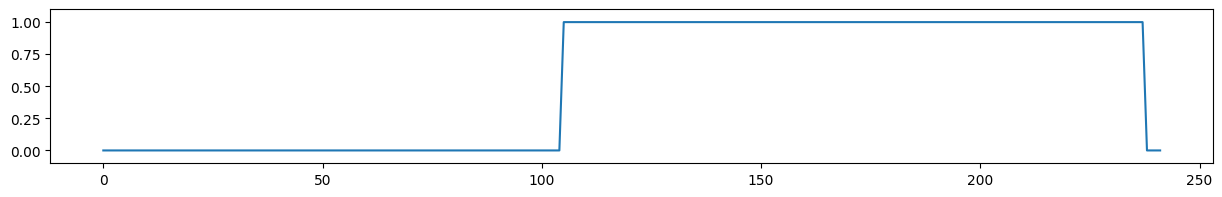

In [9]:
import matplotlib.pyplot as plt

def plot_detection(sequence):
    detected = np.any(sequence != 0, axis=1)

    plt.figure(figsize=(15,2))
    plt.plot(detected.astype(int))
    plt.ylim(-0.1,1.1)
    plt.show()


plot_detection(seq)

Inspect sequence lengths

In [10]:
print(seq.shape[0])
print(np.sum(np.any(seq != 0, axis=1)))

242
133


Check if two hands are actually used

In [11]:
left = seq[:, :63]
right = seq[:, 63:]

print(
    "left:",
    np.sum(np.any(left != 0, axis=1))
)

print(
    "right:",
    np.sum(np.any(right != 0, axis=1))
)

left: 128
right: 132


In [12]:
GREETING_5 = [
    "GOOD MORNING",
    "GOOD AFTERNOON",
    "GOOD EVENING",
    "HELLO",
    "THANK YOU"
]

greeting = manifest[
    manifest.label.isin(GREETING_5)
]

In [15]:
detected = np.any(seq != 0, axis=1)

print(detected.sum())
print(detected.mean())



detected_any = np.any(seq != 0, axis=1)

print("Detected frames:", detected_any.sum())
print("Detection rate:", detected_any.mean())



both = (
    np.any(left != 0, axis=1)
    &
    np.any(right != 0, axis=1)
)

left_only = (
    np.any(left != 0, axis=1)
    &
    ~np.any(right != 0, axis=1)
)

right_only = (
    ~np.any(left != 0, axis=1)
    &
    np.any(right != 0, axis=1)
)

none = (
    ~np.any(left != 0, axis=1)
    &
    ~np.any(right != 0, axis=1)
)

print("Both:", both.sum())
print("Left only:", left_only.sum())
print("Right only:", right_only.sum())
print("None:", none.sum())

133
0.5495867768595041
Detected frames: 133
Detection rate: 0.5495867768595041
Both: 127
Left only: 1
Right only: 5
None: 109


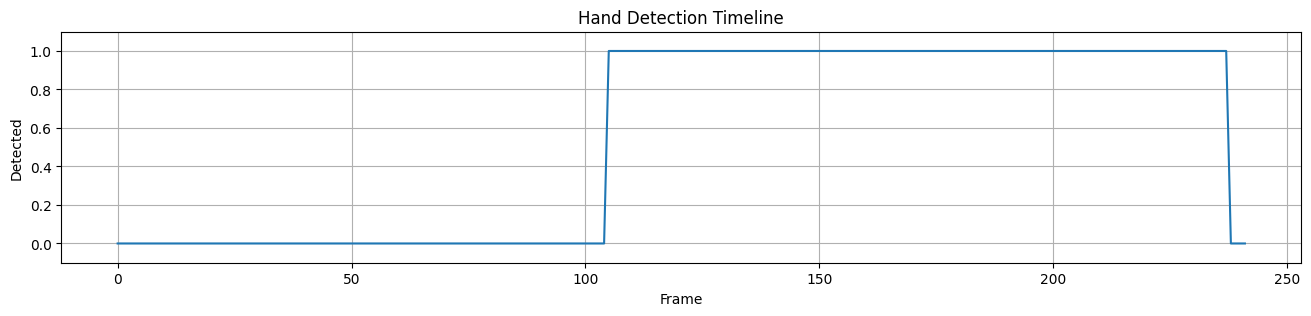

In [16]:
import matplotlib.pyplot as plt

detected = np.any(seq != 0, axis=1)

plt.figure(figsize=(16,3))
plt.plot(detected.astype(int))
plt.title("Hand Detection Timeline")
plt.xlabel("Frame")
plt.ylabel("Detected")
plt.ylim(-0.1,1.1)
plt.grid()
plt.show()

In [13]:
results = []

for _, row in greeting.iterrows():

    sequence, meta = (
        extractor.extract_video(
            row.video_path
        )
    )

    outfile = (
        SEQUENCE_DIR /
        f"{row.video_id}.npy"
    )

    np.save(
        outfile,
        sequence
    )

    status = "ok"

    if meta["detection_rate"] < 0.7:
        status = "review"

    if meta["detection_rate"] < 0.5:
        status = "bad"

    results.append({

        "video_id":
            row.video_id,

        "label":
            row.label,

        "frames":
            meta["total_frames"],

        "detected":
            meta["detected_frames"],

        "detection_rate":
            meta["detection_rate"],

        "status":
            status
    })

KeyboardInterrupt: 

In [ ]:
metadata = pd.DataFrame(results)

metadata.to_csv(
    OUTPUT /
    "extraction_metadata.csv",
    index=False
)

In [ ]:
metadata.status.value_counts()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(
    metadata.detection_rate,
    bins=20
)
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(
    metadata.frames,
    bins=20
)
plt.show()